# 🧠 JWM v2 — Scale up: d_model 384 / 8 layers (~28M) + dữ liệu grounding ×3

Rút kinh nghiệm từ v1 (10.7M): QA 56.4% nhưng grounding bão hòa ở mIoU 0.20.
**Thay đổi v2:** model ×2.6 tham số; dữ liệu ground 4K→12K (điểm nghẽn); mode-mix thiên ground
ngay từ pretrain; Platt calibration tích hợp trong notebook; bỏ ablation gap (đã kết luận ở v1).
Val/test GIỮ NGUYÊN seed và kích thước v1 → so sánh trực tiếp được.

In [1]:
# ===== Cell 1: Môi trường =====
import os, sys, json, glob, time, math, random, subprocess
import numpy as np
import torch
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams['figure.dpi'] = 90

ROOT = os.getcwd()
sys.path.insert(0, ROOT)
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
DEV = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'PyTorch {torch.__version__} | device={DEV}')
if DEV == 'cuda':
    p = torch.cuda.get_device_properties(0)
    print(f'GPU: {p.name} | VRAM {p.total_memory/1e9:.2f} GB | free before start: '
          f'{(p.total_memory - torch.cuda.memory_reserved())/1e9:.2f} GB')
T_START = time.time()

PyTorch 2.5.1+cu121 | device=cuda
GPU: NVIDIA GeForce GTX 1650 | VRAM 4.29 GB | free before start: 4.29 GB


In [2]:
# ===== Cell 2: Config v2 — scale up =====
from jwm import JWM, JWMConfig, ConvAE
cfg = JWMConfig(d_model=384, n_layers=8, n_heads=12, ffn_hidden=1024)
assert cfg.n_heads * cfg.head_dim == cfg.d_model
assert sum(cfg.rope_sections) == cfg.head_dim // 2
print(f'v2: d_model={cfg.d_model} layers={cfg.n_layers} heads={cfg.n_heads} ffn={cfg.ffn_hidden}')
r = subprocess.run([sys.executable, '-m', 'pytest', 'tests/test_jwm_math.py', '-q', '--tb=line'],
                   capture_output=True, text=True, cwd=ROOT)
print(r.stdout.strip().splitlines()[-1])
assert ' passed' in r.stdout, 'MATH TESTS FAILED'

v2: d_model=384 layers=8 heads=12 ffn=1024
25 passed in 7.56s


## §1 — Dataset v2: ground ×3, camera autotune như v1

In [3]:
# ===== Cell 3: real reference + autotune =====
from jwm.sdg import (BuildSpec, CameraParams, build_split, load_real_crops,
                     real_reference_images, validate_against_real, autotune_camera,
                     synth_background, place_objects, render_scene)
REAL = sorted(glob.glob(os.path.join(ROOT, 'data/vision_sessions/*/frames/*-raw.jpg')))
PREVIEW = os.path.join(ROOT, 'data/vision_preview.jpg')
REAL_TRAIN, REAL_VAL, REAL_TEST = REAL[:6], REAL[6:7], REAL[7:] + [PREVIEW]
real_ref = real_reference_images(REAL, per_frame=40, seed=0)
rng = random.Random(SEED)
crops_train = load_real_crops(REAL_TRAIN, per_frame=30, rng=rng)
crops_val   = load_real_crops(REAL_VAL,   per_frame=60, rng=rng)
crops_test  = load_real_crops(REAL_TEST,  per_frame=40, rng=rng)

def make_batch(cam_p, n):
    r = random.Random(777)
    out = []
    for i in range(n):
        held = r.random() < 0.4
        objs = place_objects(r, 1 if held else r.randint(1, 4), held, False)
        bg = r.choice(crops_train) if r.random() < 0.6 else synth_background(r)
        out.append(np.asarray(render_scene(objs, bg, cam_p, r), dtype=np.uint8))
    return out

cam = CameraParams()
cam, report = autotune_camera(real_ref, make_batch, cam, rounds=8, batch=200)
assert report['all_pass'], 'camera model chưa khớp real!'
print('VALIDATION vs REAL: PASS |', cam.to_dict())

[autotune r0] lum_mean:W1=9.295(ok) lum_std:W1=18.114(X) grad_energy:W1=8.864(X) log_sharpness:W1=0.956(X) color_entropy:W1=0.028(ok)
[autotune r1] lum_mean:W1=9.353(ok) lum_std:W1=10.765(ok) grad_energy:W1=5.132(X) log_sharpness:W1=0.549(ok) color_entropy:W1=0.028(ok)
[autotune r2] lum_mean:W1=9.337(ok) lum_std:W1=10.417(ok) grad_energy:W1=4.36(ok) log_sharpness:W1=0.404(ok) color_entropy:W1=0.027(ok)
VALIDATION vs REAL: PASS | {'noise_std': 8.639999999999999, 'blur_sigma': 0.405, 'jpeg_q': 55, 'brightness': 0.0, 'contrast': 1.25, 'wb_shift': 6.0, 'vignette': 0.12}


In [4]:
# ===== Cell 4: build splits v2 (val/test GIỮ NGUYÊN v1 để so sánh) =====
DATA_DIR = os.path.join(ROOT, 'data', 'jwm_sdg')
os.makedirs(DATA_DIR, exist_ok=True)
SPECS = {
    'pretrain_v2': (BuildSpec(n_qa=10000, n_ground=12000, n_fd=3000, hard=False, real_bg_ratio=0.5, seed=111), crops_train),
    'sft_v2':      (BuildSpec(n_qa=2500,  n_ground=3500,  n_fd=800,  hard=True,  real_bg_ratio=0.75, seed=222), crops_train),
    'val':         (BuildSpec(n_qa=300,   n_ground=300,   n_fd=100,  hard=True,  real_bg_ratio=0.6,  seed=303), crops_val),
    'test':        (BuildSpec(n_qa=300,   n_ground=300,   n_fd=100,  hard=True,  real_bg_ratio=0.6,  seed=404), crops_test),
}
splits = {}
for name, (spec, crops) in SPECS.items():
    f = os.path.join(DATA_DIR, f'{name}.pt')
    if name in ('val', 'test') and os.path.exists(f):
        splits[name] = torch.load(f, weights_only=False)
        print(f'{name}: reload từ đĩa (giống hệt v1)')
        continue
    t0 = time.time()
    print(f'building {name} ...')
    splits[name] = build_split(spec, cam, crops)
    torch.save(splits[name], f)
    print(f'  -> saved ({time.time()-t0:.1f}s)')
print('Tổng mẫu:', {k: len(v['qa']['q']) + len(v['ground']['q']) + len(v['fd']['q']) for k, v in splits.items()})

building pretrain_v2 ...
  built qa=10000 ground=12000 fd=3000 rejected={'dedup': 15, 'judge': 363, 'template': 210}
  -> saved (99.1s)
building sft_v2 ...
  built qa=2500 ground=3500 fd=800 rejected={'dedup': 0, 'judge': 103, 'template': 52}
  -> saved (19.8s)
val: reload từ đĩa (giống hệt v1)
test: reload từ đĩa (giống hệt v1)
Tổng mẫu: {'pretrain_v2': 25000, 'sft_v2': 6800, 'val': 700, 'test': 700}


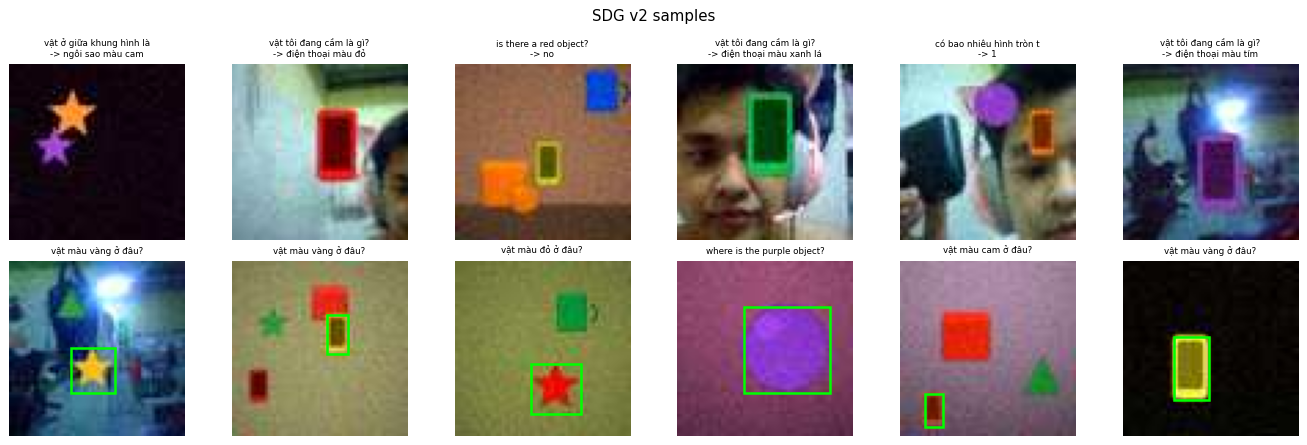

In [5]:
# ===== Cell 5: trực quan nhanh =====
from matplotlib.patches import Rectangle
d = splits['pretrain_v2']
fig, axes = plt.subplots(2, 6, figsize=(15, 5))
for j in range(6):
    ax = axes[0, j]; ax.imshow(d['qa']['img'][j].numpy()); ax.axis('off')
    ax.set_title(f"{d['qa']['q'][j][:24]}\n-> {d['qa']['a'][j]}", fontsize=7)
for j in range(6):
    ax = axes[1, j]; ax.imshow(d['ground']['img'][j].numpy()); ax.axis('off')
    cx, cy, w, h = d['ground']['bbox'][j].tolist()
    ax.add_patch(Rectangle(((cx-w/2)*64, (cy-h/2)*64), w*64, h*64, ec='lime', fc='none', lw=2))
    ax.set_title(d['ground']['q'][j][:28], fontsize=7)
plt.suptitle('SDG v2 samples'); plt.tight_layout(); plt.show()

## §2 — Model v2 + ConvAE

In [6]:
# ===== Cell 6: init =====
model = JWM(cfg)
ae = ConvAE(cfg.z_ch)
print(f'JWM v2: {model.num_params()/1e6:.2f}M params (v1: 10.74M)')
from jwm.trainer import train_convae
hist_ae = train_convae(ae, splits['pretrain_v2']['qa']['img'], DEV, steps=800, bs=64, log_every=200)

JWM v2: 31.01M params (v1: 10.74M)
  [convae    0/800] recon_mse=0.09295  psnr=10.74dB
  [convae  200/800] recon_mse=0.00450  psnr=24.04dB
  [convae  400/800] recon_mse=0.00279  psnr=26.53dB
  [convae  600/800] recon_mse=0.00229  psnr=27.28dB
  [convae  799/800] recon_mse=0.00239  psnr=27.20dB


## §3 — Stage 1 Pretrain (6000 bước, ground-heavy từ đầu)

In [7]:
# ===== Cell 7: pretrain =====
from jwm.trainer import train_stage, eval_qa, eval_ground, eval_fd, measure_latency
hist1 = train_stage(model, ae, splits['pretrain_v2'], cfg, DEV,
                    steps=6000, lr=3e-4, batch_size=48, warmup=200,
                    mode_probs={'qa': 0.30, 'ground': 0.50, 'fd': 0.20},
                    seed=SEED, log_every=200)
print(f'peak VRAM: {torch.cuda.max_memory_allocated()/1e9:.2f} GB')

  [    0/6000] mode=ground loss=12.5366 bbox_flow=1.2503 conf_bce=0.6753 iou_1step=0.1092 | 1.0 it/s
  [  200/6000] mode=qa     loss=2.4773 qa_ce=2.4773 qa_tok_acc=0.8007 | 0.7 it/s
  [  400/6000] mode=ground loss=3.8158 bbox_flow=0.3797 conf_bce=0.3771 iou_1step=0.1913 | 0.7 it/s
  [  600/6000] mode=fd     loss=0.7838 fd_flow=0.7838 | 0.7 it/s


KeyboardInterrupt: 

In [ ]:
# ===== Cell 8: loss curves =====
def rolling(xs, k=25):
    out = []
    for i in range(len(xs)):
        lo = max(0, i-k)
        out.append(sum(xs[lo:i+1])/(i+1-lo))
    return out
fig, axes = plt.subplots(1, 3, figsize=(15, 3))
for ax, m in zip(axes, ['qa', 'ground', 'fd']):
    st = [s for s, mm in zip(hist1['step'], hist1['mode']) if mm == m]
    ls = [l for l, mm in zip(hist1['loss'], hist1['mode']) if mm == m]
    ax.plot(st, ls, alpha=0.25, lw=0.6); ax.plot(st, rolling(ls), lw=1.8)
    ax.set_title(f'v2 pretrain — {m}'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## §4 — Stage 2 SFT (1500 bước)

In [ ]:
# ===== Cell 9: SFT =====
hist2 = train_stage(model, ae, splits['sft_v2'], cfg, DEV,
                    steps=1500, lr=8e-5, batch_size=48, warmup=80,
                    mode_probs={'qa': 0.25, 'ground': 0.55, 'fd': 0.20},
                    seed=SEED + 1, log_every=200)

## §5 — Đánh giá VAL + Platt calibration (tích hợp)

In [ ]:
# ===== Cell 10: val eval =====
qa_val = eval_qa(model, splits['val'], cfg, DEV, n=250)
gr_50 = eval_ground(model, ae, splits['val'], cfg, DEV, n=250, steps=50)
gr_4  = eval_ground(model, ae, splits['val'], cfg, DEV, n=250, steps=4)
fd_val = eval_fd(model, ae, splits['val'], cfg, DEV, n=48, k=4, steps=50)

In [ ]:
# ===== Cell 11: Platt calibration trên val @4 steps =====
from jwm.mathx import expected_calibration_error
conf_v = torch.tensor(gr_4['conf_all']).clamp(1e-4, 1 - 1e-4)
y_v = torch.tensor(gr_4['iou_all']) >= 0.5
logit_v = torch.log(conf_v / (1 - conf_v))
a = torch.tensor(1.0, requires_grad=True); b = torch.tensor(0.0, requires_grad=True)
opt = torch.optim.LBFGS([a, b], lr=0.1, max_iter=200)
def closure():
    opt.zero_grad()
    loss = torch.nn.functional.binary_cross_entropy_with_logits(a * logit_v + b, y_v.float())
    loss.backward(); return loss
opt.step(closure)
a_f, b_f = float(a), float(b)
cal = lambda c: torch.sigmoid(a_f * torch.log(c / (1 - c)) + b_f)
print(f'Platt: a={a_f:.3f} b={b_f:.3f}')
print(f'val ECE: {expected_calibration_error(conf_v, y_v):.4f} -> {expected_calibration_error(cal(conf_v), y_v):.4f}')
CALIBRATION = {'a': round(a_f, 4), 'b': round(b_f, 4), 'steps': 4}

In [ ]:
# ===== Cell 12: bbox overlay + reliability =====
from matplotlib.patches import Rectangle
iou = torch.tensor(gr_4['iou_all']); confc = cal(torch.tensor(gr_4['conf_all']).clamp(1e-4, 1-1e-4))
fig, axes = plt.subplots(1, 3, figsize=(14, 3))
axes[0].hist(iou.numpy(), bins=20); axes[0].axvline(0.5, color='r', ls='--')
axes[0].set_title(f"IoU dist 4-step (mIoU={gr_4['miou']:.3f})")
bins = torch.linspace(0, 1, 11); accs, cs = [], []
for i in range(10):
    m = (confc >= bins[i]) & (confc < bins[i+1])
    if m.sum() > 2:
        accs.append(float((iou[m] >= 0.5).float().mean())); cs.append(float(confc[m].mean()))
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.5); axes[1].plot(cs, accs, 'o-')
axes[1].set_title('Reliability SAU calibration')
dv = splits['val']['ground']
axes[2].axis('off')
plt.tight_layout(); plt.show()
fig, axes = plt.subplots(1, 8, figsize=(16, 2.3))
for j, ax in enumerate(axes):
    ax.imshow(dv['img'][j].numpy()); ax.axis('off')
    r = gr_4['records'][j]
    for bb, col in [(r['gt'], 'lime'), (r['bbox'], 'red')]:
        cx, cy, w, h = bb
        ax.add_patch(Rectangle(((cx-w/2)*64, (cy-h/2)*64), w*64, h*64, ec=col, fc='none', lw=1.8))
    ax.set_title(f"IoU={r['iou']:.2f}", fontsize=7)
plt.suptitle('v2 GROUND: pred (đỏ) vs gt (xanh)'); plt.tight_layout(); plt.show()

## §6 — TEST cuối + latency + save jwm_v2.pt

In [ ]:
# ===== Cell 13: final test + save =====
print('=== TEST SET (so sánh trực tiếp với v1) ===')
qa_t = eval_qa(model, splits['test'], cfg, DEV, n=250)
gr_t = eval_ground(model, ae, splits['test'], cfg, DEV, n=250, steps=50)
gr_t4 = eval_ground(model, ae, splits['test'], cfg, DEV, n=250, steps=4)
fd_t = eval_fd(model, ae, splits['test'], cfg, DEV, n=48, k=4, steps=50)
lat = measure_latency(model, ae, splits['val'], cfg, DEV, reps=15)
conf_t = torch.tensor(gr_t4['conf_all']).clamp(1e-4, 1-1e-4)
y_t = torch.tensor(gr_t4['iou_all']) >= 0.5
ece_after = expected_calibration_error(cal(conf_t), y_t)
print(f'test ECE sau calibration: {ece_after:.4f}')

CKPT_DIR = os.path.join(ROOT, 'jwm', 'checkpoints')
metrics = {
 'v1_test_reference': {'qa_acc': 0.564, 'miou': 0.201, 'iou_at_05_4step': 0.184, 'ece_cal': 0.0396,
                       'fd_psnr': 20.10, 'fd_copy': 21.39, 'params_M': 10.74},
 'val': {'qa_acc': qa_val['acc'], 'iou_at_05': gr_50['iou_at_05'], 'miou_50': gr_50['miou'],
         'miou_4step': gr_4['miou'], 'iou_at_05_4step': gr_4['iou_at_05'],
         'fd_psnr': fd_val['fd_psnr_min_over_k'], 'fd_copy': fd_val['fd_psnr_copy_baseline']},
 'test': {'qa_acc': qa_t['acc'], 'qa_per_kind': qa_t['per_kind'],
          'iou_at_05': gr_t['iou_at_05'], 'miou': gr_t['miou'],
          'iou_at_05_4step': gr_t4['iou_at_05'], 'miou_4step': gr_t4['miou'],
          'ece_calibrated_4step': ece_after,
          'fd_psnr': fd_t['fd_psnr_min_over_k'], 'fd_copy': fd_t['fd_psnr_copy_baseline'],
          'fd_beats_copy': fd_t['beats_copy_frac']},
 'calibration': CALIBRATION, 'latency_ms': lat, 'params_M': model.num_params() / 1e6,
 'train': {'pretrain_steps': 6000, 'sft_steps': 1500, 'seed': SEED,
           'data': 'pretrain_v2 25K / sft_v2 6.8K, ground-heavy'},
}
torch.save({'model': model.state_dict(), 'ae': ae.state_dict(), 'cfg': cfg.__dict__,
            'camera': cam.to_dict(), 'calibration': CALIBRATION, 'metrics': metrics},
           os.path.join(CKPT_DIR, 'jwm_v2.pt'))
json.dump(metrics, open(os.path.join(CKPT_DIR, 'metrics_v2.json'), 'w'), ensure_ascii=False, indent=1)
print(json.dumps(metrics['test'], ensure_ascii=False, indent=1))
print(f'Saved jwm_v2.pt | tổng thời gian: {(time.time()-T_START)/60:.1f} phút')

In [8]:
# ===== SAFETY CHECKPOINT (người dùng cần tắt máy) =====
# Train bị ngắt chủ động ở ~step 450; trọng số hiện tại vẫn trong RAM -> lưu xuống đĩa.
import os, json, time, torch, re
APPROX = 0
for _h in [globals().get("hist1")]:
    pass
try:
    APPROX = len(hist1["step"]) if "hist1" in dir() else 0
except Exception:
    APPROX = 0
CKPT_DIR = os.path.join(ROOT, 'jwm', 'checkpoints')
os.makedirs(CKPT_DIR, exist_ok=True)
torch.save({'model': model.state_dict(), 'ae': ae.state_dict(), 'cfg': cfg.__dict__,
            'camera': cam.to_dict(),
            'resume': {'stage': 'pretrain', 'approx_step': APPROX, 'total_pretrain': 6000,
                       'sft_steps': 1500, 'saved_at': time.strftime('%Y-%m-%dT%H:%M:%S')}},
           os.path.join(CKPT_DIR, 'jwm_v2_partial.pt'))
print('SAVED jwm_v2_partial.pt — an toàn để tắt máy.')
print('Resume sau khi mở máy:  python scripts/resume_v2_training.py')

SAVED jwm_v2_partial.pt — an toàn để tắt máy.
Resume sau khi mở máy:  python scripts/resume_v2_training.py
